# Data Augmentation

## Introduction

Now that you've learned the fundamentals of convolutional classifiers, you're ready to 
move on to more advanced topics.

In this lesson, you'll learn a trick that can give a boost to your image classifiers: 
it's called **data augmentation**.

---

## The Usefulness of Fake Data

The best way to improve the performance of a machine learning model is to train it on 
**more data**. The more examples the model has to learn from, the better it will be able 
to recognize which differences in images matter and which do not. More data helps the 
model to **generalize** better.

One easy way of getting more data is to use the data you already have. If we can 
transform the images in our dataset in ways that **preserve the class**, we can teach our 
classifier to ignore those kinds of transformations.

> For instance, whether a car is facing left or right in a photo doesn't change the fact 
> that it is a Car and not a Truck. So, if we augment our training data with flipped 
> images, our classifier will learn that "left or right" is a difference it should ignore.

That's the whole idea behind data augmentation: **add in some extra fake data** that looks 
reasonably like the real data and your classifier will improve.

---

## Using Data Augmentation

Typically, many kinds of transformation are used when augmenting a dataset:

- 🔄 Rotating the image
- 🎨 Adjusting color or contrast
- 🪞 Flipping horizontally or vertically
- 🔍 Zooming in or out
- ↔️ Shifting / warping the image

These are usually applied **in combination** and **randomly** each time an image is used.

Data augmentation is done **online** — as images are fed into the network for training. 
Each time an image is used during training, a **new random transformation** is applied. 
This way, the model is always seeing something a little different than what it's seen 
before. This extra variance is what helps the model generalize to new data.

> ⚠️ **Important:** Not every transformation will be useful on every problem.  
> Whatever transformations you use should **not mix up the classes**.  
> For example, rotating digits would mix up `9`s and `6`s — a bad augmentation for a 
> digit recognizer!  
> The best approach: **try it and see.**

---

## Example — Training with Data Augmentation

Keras lets you augment your data in two ways:

| Method | Where it runs | How |
|--------|--------------|-----|
| `ImageDataGenerator` | In the data pipeline | CPU |
| Keras preprocessing layers | Inside the model definition | **GPU** ✅ (faster) |

We'll use the **preprocessing layers** approach — the image transformations will be 
computed on the **GPU** instead of the CPU, potentially speeding up training.


In [1]:
# Imports
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Reproducibility
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    # os.environ['TF_DETERMINISTIC_OPS'] = '1'  # commented out (can slow GPU)
set_seed()

# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore")

# Load training and validation sets
ds_train_ = image_dataset_from_directory(
    '../dataset/car_truck',      # ← local path
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=31415,
)
ds_valid_ = image_dataset_from_directory(
    '../dataset/car_truck',      # ← local path
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,
    validation_split=0.2,
    subset='validation',
    seed=31415,
)

# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)


Found 180 files belonging to 2 classes.
Using 144 files for training.
Found 180 files belonging to 2 classes.
Using 36 files for validation.


---

## Step 2 — Define Model

To illustrate the effect of augmentation, we'll add a couple of simple transformations 
to the model from Lesson 5.

The two augmentation layers are added **at the very start** of the model, before the 
pretrained VGG16 base:

| Augmentation | What it does |
|---|---|
| `RandomFlip('horizontal')` | Randomly mirrors the image left↔right (50% chance each batch) |
| `RandomContrast(0.5)` | Randomly adjusts contrast by up to ±50% |

These transformations are only applied **during training** — during validation and 
inference, the layers pass the image through unchanged. This means the model trains 
on slightly different versions of each image every epoch, helping it generalize better.



In [3]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import RandomFlip, RandomContrast

# Load VGG16 pretrained base
pretrained_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=[128, 128, 3]
)
pretrained_base.trainable = False  # freeze base weights

model = keras.Sequential([
    # Preprocessing (Data Augmentation)
    RandomFlip('horizontal'),   # flip left-to-right
    RandomContrast(0.5),        # contrast change by up to 50%
    # Base
    pretrained_base,
    # Head
    layers.Flatten(),
    layers.Dense(6, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

---

## Step 3 — Train and Evaluate

Now we compile and train the model. Since we're using a **pretrained VGG16 base**, 
the model already knows how to extract good features — so it should converge much 
faster than training from scratch (Lesson 5).


In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=30,
    verbose=1,
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 610ms/step - binary_accuracy: 0.8681 - loss: 0.4167 - val_binary_accuracy: 0.9167 - val_loss: 0.4637
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 566ms/step - binary_accuracy: 0.9375 - loss: 0.3639 - val_binary_accuracy: 0.7222 - val_loss: 0.5812
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 575ms/step - binary_accuracy: 0.8681 - loss: 0.3260 - val_binary_accuracy: 0.9167 - val_loss: 0.3392
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 620ms/step - binary_accuracy: 0.9375 - loss: 0.2220 - val_binary_accuracy: 1.0000 - val_loss: 0.1085
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 619ms/step - binary_accuracy: 0.9444 - loss: 0.1851 - val_binary_accuracy: 0.8611 - val_loss: 0.3017
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 611ms/step - binary_accuracy: 0.9375 - loss: 0.1799 - val_binary_accuracy: 0.9167 - val_loss: 0.2296
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 611ms/step - binary_accuracy: 0.9792 - loss: 0.1142 - val_binary_accuracy: 0.9722 - val_loss: 0.0932
Epoch 8/30
3/3 ━━━━━

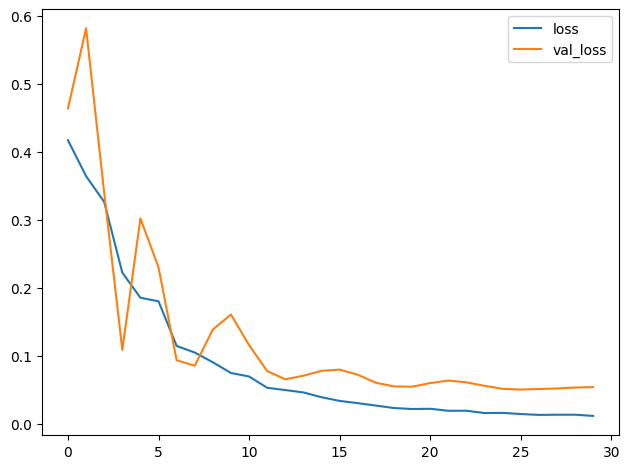

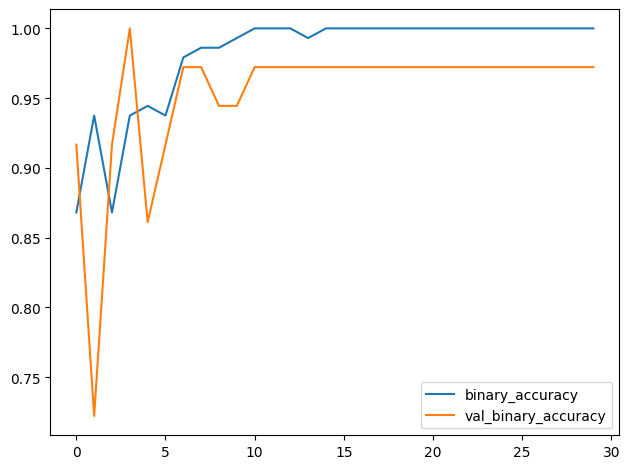

In [8]:
import pandas as pd

history_frame = pd.DataFrame(history.history)

history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();

---

## Training Results — Analysis

### Results at a Glance

| Metric | Value |
|--------|-------|
| Epochs to converge | ~10 |
| Final train accuracy | ~100% |
| Final val accuracy | ~97% |
| Final train loss | ~0.01 |
| Final val loss | ~0.06 |

### What the curves show

**Loss curve:**
- Train loss dropped smoothly from **0.41 → 0.01** — clean, stable learning
- Val loss settled around **0.06** — model generalizes well to unseen images
- Early spikes (epochs 0–6) are caused by the small validation set, not real instability

**Accuracy curve:**
- Train accuracy reached **~100% by epoch 10** and stayed flat
- Val accuracy stabilized at **~97%** — strong real-world performance

### Slight overfitting

Train loss (~0.01) is lower than val loss (~0.06) — the model fits training data 
slightly better than validation data. This is a mild sign of overfitting, but the 
high val accuracy (97%) shows it's still generalizing well.

---

### Comparison — Lesson 5 (scratch) vs Lesson 6 (VGG16 + augmentation)

| | Lesson 5 | Lesson 6 |
|---|---|---|
| Starting loss | ~2.50 | **~0.41** |
| Epochs to converge | ~80 | **~10** |
| Final val accuracy | ~100% | **~97%** |
| Training stability | Very noisy | **Much smoother** |

> ✅ **Conclusion:** Transfer learning with VGG16 + data augmentation converges 
> **8× faster** with far more stable training curves.  
> Pretrained models bring millions of ImageNet features for free — you only need to 
> train the small head on your own data.
